In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import label_binarize

# Load the data from the provided CSV file
data_path = '/data/0shared/lijun/code/Spike_detection/Models/YOUR_MODEL_NAME/predictions.csv'
data = pd.read_csv(data_path)

# Dropping the unnecessary columns as per user request
data_cleaned = data.drop(columns=['preds', 'event_file', 'fraction_of_yes', 'Mode'])

# Separating the features and the target variable
X = data_cleaned.drop('location', axis=1)
y = data_cleaned['location']



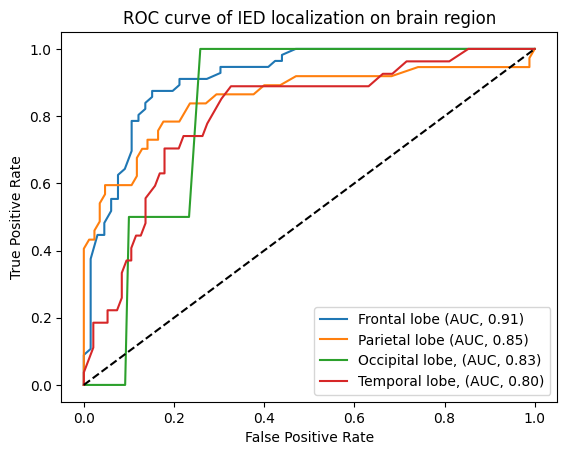

Accuracy: 0.6967213114754098
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        56
           1       0.63      0.65      0.64        37
           2       0.00      0.00      0.00         2
           3       0.57      0.44      0.50        27

    accuracy                           0.70       122
   macro avg       0.50      0.49      0.49       122
weighted avg       0.69      0.70      0.69       122

AUC Scores:
  Class 0: 0.9132846320346322
  Class 1: 0.8532591414944356
  Class 2: 0.8291666666666666
  Class 3: 0.8037037037037037


In [13]:
# Corrected code execution with 5 classes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Load the data from the provided CSV file
data_path = './conbine_localization_predictions.csv'
data = pd.read_csv(data_path)

# Splitting the data based on the 'Mode' column
train_data = data[data['Mode'] == 'train']
test_data = data[data['Mode'] == 'test']

# Dropping the unnecessary columns as per user request
train_data_cleaned = train_data.drop(columns=['preds', 'event_file', 'fraction_of_yes', 'Mode'])
test_data_cleaned = test_data.drop(columns=['preds', 'event_file', 'fraction_of_yes', 'Mode'])

# Separating the features and the target variable
X_train = train_data_cleaned.drop('location', axis=1)
y_train = train_data_cleaned['location']
X_test = test_data_cleaned.drop('location', axis=1)
y_test = test_data_cleaned['location']

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and training the RandomForest model
rf_model = RandomForestClassifier(random_state=2)
rf_model.fit(X_train_scaled, y_train)

# Predicting the test set results
y_pred = rf_model.predict(X_test_scaled)
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3])
y_pred_prob = rf_model.predict_proba(X_test_scaled)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Calculate AUC for each class
auc_scores = {}
auc_scores = {}
fpr, tpr, _ = roc_curve(y_test_binarized[:, 0], y_pred_prob[:, 0])
auc_scores[f'Class {0}'] = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Frontal lobe (AUC, {auc_scores[f"Class {0}"]:.2f})')

fpr, tpr, _ = roc_curve(y_test_binarized[:, 1], y_pred_prob[:, 1])
auc_scores[f'Class {1}'] = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Parietal lobe (AUC, {auc_scores[f"Class {1}"]:.2f})')

fpr, tpr, _ = roc_curve(y_test_binarized[:, 2], y_pred_prob[:, 2])
auc_scores[f'Class {2}'] = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Occipital lobe, (AUC, {auc_scores[f"Class {2}"]:.2f})')

fpr, tpr, _ = roc_curve(y_test_binarized[:, 3], y_pred_prob[:, 3])
auc_scores[f'Class {3}'] = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Temporal lobe, (AUC, {auc_scores[f"Class {3}"]:.2f})')


# Plotting the ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of IED localization on brain region')
plt.legend(loc="lower right")
plt.show()

# Display the results
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_rep)
print("AUC Scores:")
for class_label, auc_score in auc_scores.items():
    print(f"  {class_label}: {auc_score}")


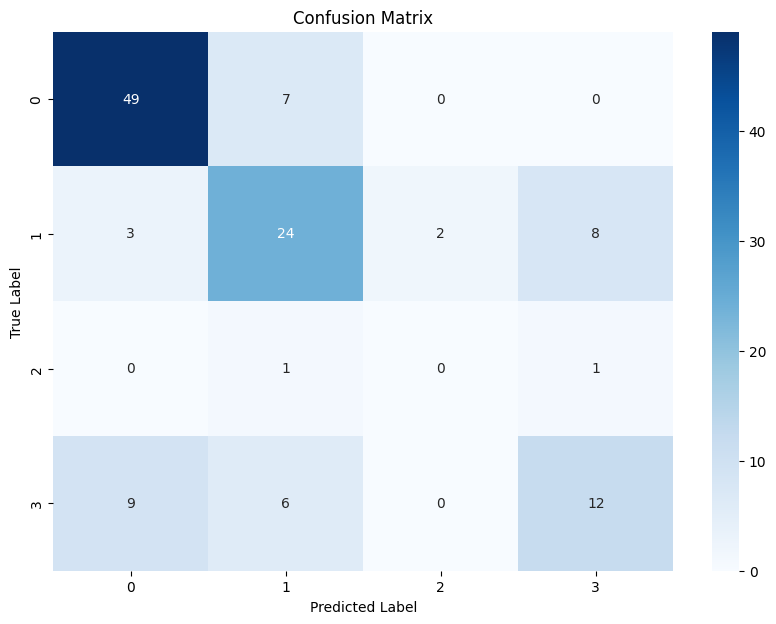

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=True, yticklabels=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
